[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lasseufpa/dsp2026/blob/main/notebooks/exemplos/examples_2a.ipynb)

In [1]:
# Install all required packages
%pip install -q numpy pandas matplotlib plotly nbformat pillow

Note: you may need to restart the kernel to use updated packages.


## Example 1: DCT Transform Coding (energy compaction) for time-series compression/approximation

We load monthly car sales values from a public CSV, center the data, compute the DCT, and inspect how few coefficients capture most of the signal energy.

Public dataset source used in this example:
- Monthly Car Sales (Quebec, 1960-1968) (https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

plt.style.use("seaborn-v0_8-whitegrid")

# DCT-II (orthonormal) and inverse DCT via direct cosine basis.
def dct_ortho(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    N = x.size
    n = np.arange(N)
    k = n[:, None]
    basis = np.cos(np.pi * (n + 0.5) * k / N)
    X = basis @ x
    X[0] *= np.sqrt(1.0 / N)
    X[1:] *= np.sqrt(2.0 / N)
    return X


def idct_ortho(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=float)
    N = X.size
    n = np.arange(N)[:, None]
    k = np.arange(N)
    alpha = np.full(N, np.sqrt(2.0 / N))
    alpha[0] = np.sqrt(1.0 / N)
    x = np.sum(alpha * X * np.cos(np.pi * (n + 0.5) * k / N), axis=1)
    return x

In [3]:
DATA_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv"

df = pd.read_csv(DATA_URL, parse_dates=["Month"])
df.columns = ["month", "sales"]

x = df["sales"].to_numpy(dtype=float)
time = df["month"]

print(f"Loaded {len(df)} monthly samples from: {DATA_URL}")
df.head()

Loaded 108 monthly samples from: https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv


,month,sales
0,1960-01-01,6550
1,1960-02-01,8728
2,1960-03-01,12026
3,1960-04-01,14395
4,1960-05-01,14587


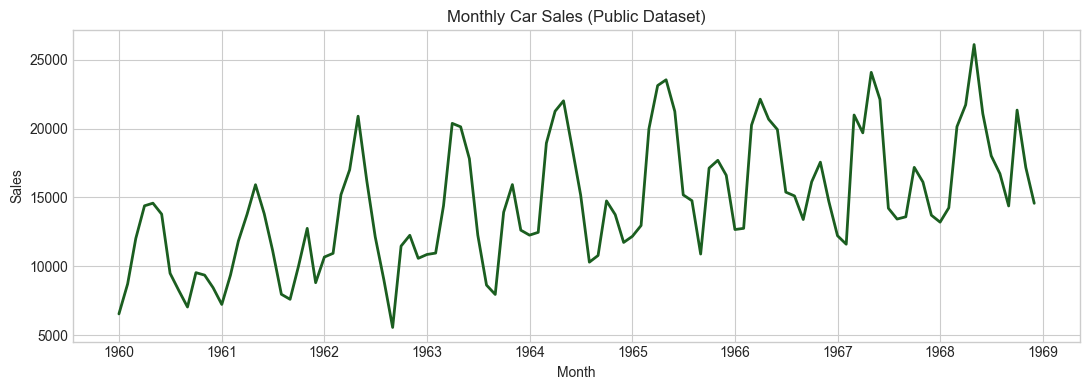

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(time, x, lw=2, color="#1b5e20")
ax.set_title("Monthly Car Sales (Public Dataset)")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
plt.tight_layout()
plt.show()

Coefficients for 95% energy: 55
Coefficients for 99% energy: 92


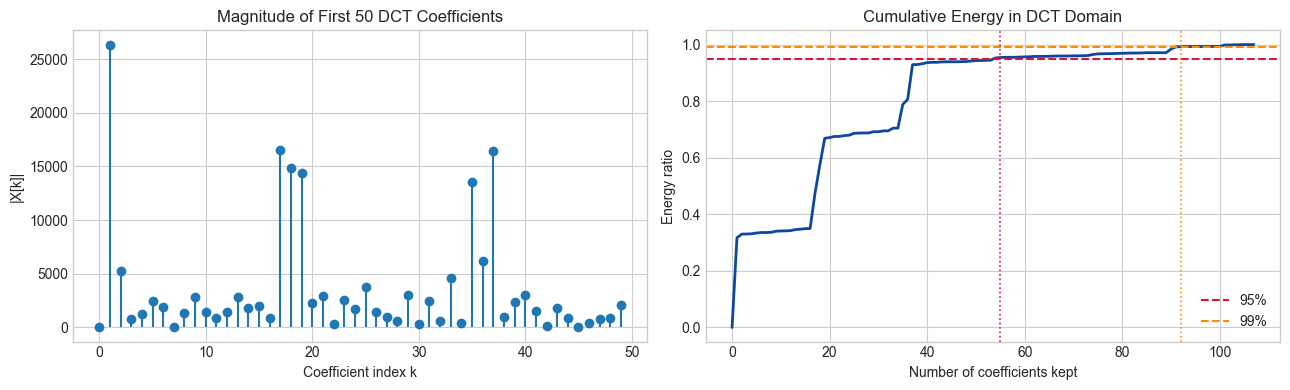

In [5]:
x_centered = x - np.mean(x)
X = dct_ortho(x_centered)
energy = np.cumsum(X**2) / np.sum(X**2)

k95 = int(np.searchsorted(energy, 0.95) + 1)
k99 = int(np.searchsorted(energy, 0.99) + 1)
print(f"Coefficients for 95% energy: {k95}")
print(f"Coefficients for 99% energy: {k99}")

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].stem(np.arange(50), np.abs(X[:50]), basefmt=" ")
axs[0].set_title("Magnitude of First 50 DCT Coefficients")
axs[0].set_xlabel("Coefficient index k")
axs[0].set_ylabel("|X[k]|")

axs[1].plot(energy, color="#0d47a1", lw=2)
axs[1].axhline(0.95, color="crimson", ls="--", lw=1.5, label="95%")
axs[1].axhline(0.99, color="darkorange", ls="--", lw=1.5, label="99%")
axs[1].axvline(k95, color="crimson", ls=":", lw=1.2)
axs[1].axvline(k99, color="darkorange", ls=":", lw=1.2)
axs[1].set_title("Cumulative Energy in DCT Domain")
axs[1].set_xlabel("Number of coefficients kept")
axs[1].set_ylabel("Energy ratio")
axs[1].legend()

plt.tight_layout()
plt.show()

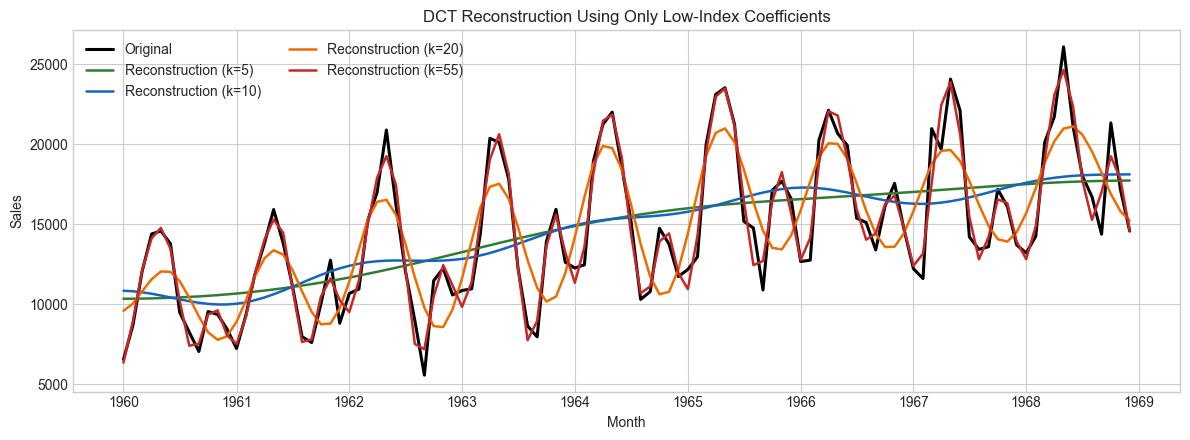

k=  5 -> RMSE = 3684.141
k= 10 -> RMSE = 3659.092
k= 20 -> RMSE = 2592.633
k= 55 -> RMSE = 981.010


In [6]:
def keep_first_k_coeffs(X: np.ndarray, k: int) -> np.ndarray:
    Xk = np.zeros_like(X)
    Xk[:k] = X[:k]
    return Xk

k_values = [5, 10, 20, k95]
recon = {}
for k in k_values:
    x_hat = idct_ortho(keep_first_k_coeffs(X, k)) + np.mean(x)
    recon[k] = x_hat

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(time, x, color="black", lw=2.2, label="Original")
colors = ["#2e7d32", "#1565c0", "#ef6c00", "#c62828"]
for k, c in zip(k_values, colors):
    ax.plot(time, recon[k], lw=1.8, color=c, label=f"Reconstruction (k={k})")

ax.set_title("DCT Reconstruction Using Only Low-Index Coefficients")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

for k in k_values:
    rmse = float(np.sqrt(np.mean((x - recon[k])**2)))
    print(f"k={k:>3} -> RMSE = {rmse:.3f}")

Notice how most energy is concentrated in low-index coefficients, showing compact representation for smooth trends.

In summary, we applied the DCT to the monthly car sales time series to analyze the cumulative energy in the DCT domain. With that info we reconstructed the signal using only the first \(k\) DCT coefficients and compared reconstruction errors.

We can achieve 95% of the signal energy is captured with 55 coefficients and 99% of the signal energy is captured with 92 coefficients.

This way we can confirms the energy compaction property of the DCT: most
relevant information is concentrated in lower-index coefficients. Therefore, DCT
is effective for compact representation and lossy compression-style
approximation of smooth or trend+seasonality signals.

## Example 2: DCT image compression

This example shows a classic transform coding workflow (similar to the core idea behind JPEG):
First we compute the 2D DCT of an image. Then we keep only low-frequency coefficients (top-left region in the DCT matrix).
Finally, we construct the image with inverse DCT and compare quality.

We use a public image from the scikit-image repository.

Loaded image from: https://raw.githubusercontent.com/scikit-image/scikit-image/v0.21.0/skimage/data/camera.png


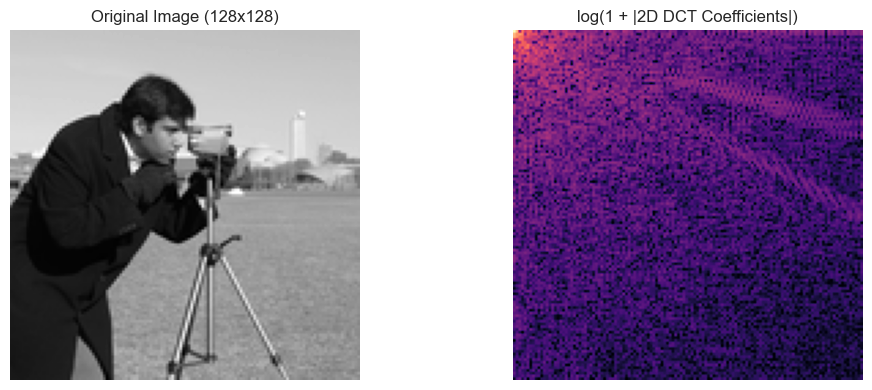

In [7]:
from io import BytesIO
from urllib.request import urlopen
from PIL import Image

IMG_URLS = [
    "https://raw.githubusercontent.com/scikit-image/scikit-image/v0.21.0/skimage/data/camera.png",
]

# Load a public image, convert to grayscale, and resize for fast matrix-based DCT.
resample = Image.Resampling.LANCZOS if hasattr(Image, "Resampling") else Image.LANCZOS
img = None
last_error = None

for url in IMG_URLS:
    try:
        img = Image.open(BytesIO(urlopen(url).read())).convert("L").resize((128, 128), resample=resample)
        img_source = url
        break
    except Exception as err:
        last_error = err

if img is None:
    raise RuntimeError(f"Could not load any public image URL. Last error: {last_error}")

img_arr = np.asarray(img, dtype=float)
print(f"Loaded image from: {img_source}")


def dct_basis(N: int) -> np.ndarray:
    n = np.arange(N)
    k = n[:, None]
    C = np.sqrt(2.0 / N) * np.cos(np.pi * (n + 0.5) * k / N)
    C[0, :] = np.sqrt(1.0 / N)
    return C


def dct2_ortho(image: np.ndarray):
    h, w = image.shape
    Ch = dct_basis(h)
    Cw = dct_basis(w)
    coeff = Ch @ image @ Cw.T
    return coeff, Ch, Cw


def idct2_ortho(coeff: np.ndarray, Ch: np.ndarray, Cw: np.ndarray) -> np.ndarray:
    return Ch.T @ coeff @ Cw

D_img, Ch, Cw = dct2_ortho(img_arr)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].imshow(img_arr, cmap="gray", vmin=0, vmax=255)
axs[0].set_title("Original Image (128x128)")
axs[0].axis("off")

axs[1].imshow(np.log1p(np.abs(D_img)), cmap="magma")
axs[1].set_title("log(1 + |2D DCT Coefficients|)")
axs[1].axis("off")

plt.tight_layout()
plt.show()

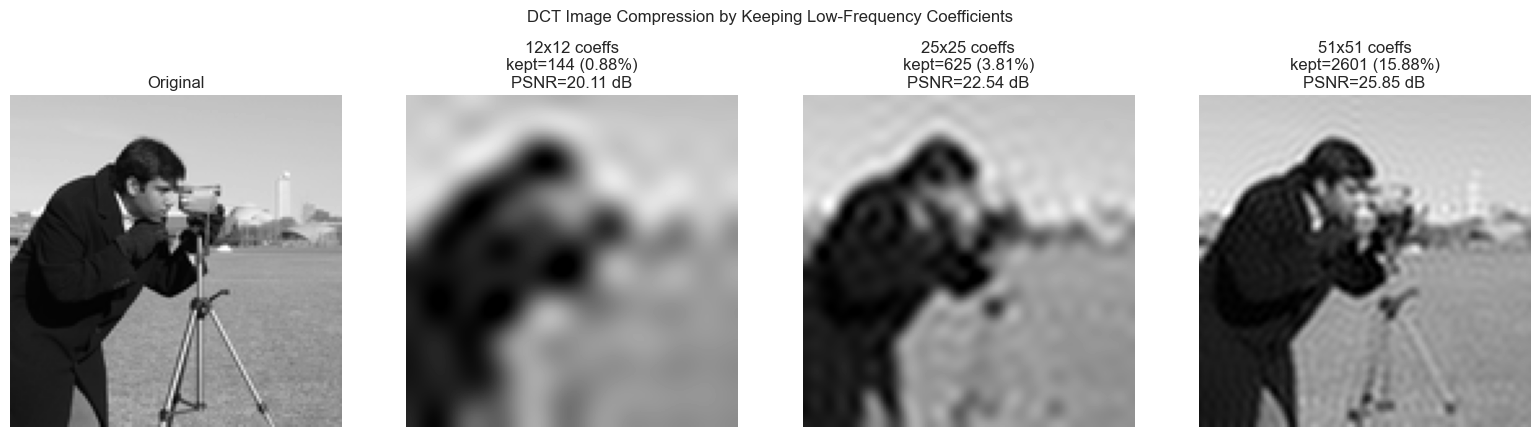

In [8]:
def compress_with_low_freq_block(D: np.ndarray, fraction: float) -> tuple:
    h, w = D.shape
    kh = max(1, int(h * np.sqrt(fraction)))
    kw = max(1, int(w * np.sqrt(fraction)))
    mask = np.zeros_like(D)
    mask[:kh, :kw] = 1.0
    Dk = D * mask
    kept = kh * kw
    return Dk, kh, kw, kept


def psnr_db(original: np.ndarray, reconstructed: np.ndarray, peak: float = 255.0) -> float:
    mse = float(np.mean((original - reconstructed) ** 2))
    if mse == 0:
        return float("inf")
    return 10.0 * np.log10((peak ** 2) / mse)

fractions = [0.01, 0.04, 0.16]
results = []

for frac in fractions:
    Dk, kh, kw, kept = compress_with_low_freq_block(D_img, frac)
    rec = np.clip(idct2_ortho(Dk, Ch, Cw), 0, 255)
    ratio = kept / D_img.size
    results.append((frac, rec, kh, kw, kept, ratio, psnr_db(img_arr, rec)))

fig, axs = plt.subplots(1, 4, figsize=(16, 4.2))
axs[0].imshow(img_arr, cmap="gray", vmin=0, vmax=255)
axs[0].set_title("Original")
axs[0].axis("off")

for i, (_, rec, kh, kw, kept, ratio, psnr) in enumerate(results, start=1):
    axs[i].imshow(rec, cmap="gray", vmin=0, vmax=255)
    axs[i].set_title(
        f"{kh}x{kw} coeffs\nkept={kept} ({100*ratio:.2f}%)\nPSNR={psnr:.2f} dB"
    )
    axs[i].axis("off")

plt.suptitle("DCT Image Compression by Keeping Low-Frequency Coefficients", y=1.03)
plt.tight_layout()
plt.show()

## Example 3: Interactive DFT analysis

In this example we build a signal by summing multiple sine components, then
analyze it with a 3D time-domain view showing each component and the final
mixture. Then, we use DFT and show a chart to identify dominant frequencies.
Finally, there is an interactive 3D spectrogram to see how frequency content evolves over time.

In [9]:
# Build a signal composed of multiple sine waves with different active intervals.
fs = 240  # Hz
T = 5.0   # seconds
t = np.arange(0, T, 1 / fs)

components = [
    {"name": "6 Hz", "amp": 1.0, "freq": 6.0, "phase": 0.0, "start": 0.0, "end": 2.2, "color": "#1f77b4"},
    {"name": "14 Hz", "amp": 0.9, "freq": 14.0, "phase": 0.4, "start": 1.0, "end": 4.0, "color": "#ff7f0e"},
    {"name": "32 Hz", "amp": 0.6, "freq": 32.0, "phase": -0.2, "start": 2.4, "end": T, "color": "#2ca02c"},
]

component_signals = []
for comp in components:
    active = (t >= comp["start"]) & (t < comp["end"])
    y = comp["amp"] * np.sin(2 * np.pi * comp["freq"] * t + comp["phase"]) * active
    component_signals.append(y)

signal = np.sum(component_signals, axis=0)

# Interactive 3D chart: each component on a separate lane, plus the resulting mixture.
fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=t,
        y=np.zeros_like(t),
        z=signal,
        mode="lines",
        name="Mixture",
        line=dict(color="#111111", width=7),
        hovertemplate="t=%{x:.3f} s<br>Mixture=%{z:.3f}<extra></extra>",
    )
)

for i, (comp, y_comp) in enumerate(zip(components, component_signals), start=1):
    fig.add_trace(
        go.Scatter3d(
            x=t,
            y=np.full_like(t, i, dtype=float),
            z=y_comp,
            mode="lines",
            name=f"Component {comp['name']}",
            line=dict(color=comp["color"], width=5),
            hovertemplate=(
                f"{comp['name']}<br>t=%{{x:.3f}} s<br>Amplitude=%{{z:.3f}}<extra></extra>"
            ),
        )
    )

lane_labels = ["Mixture"] + [f"Component {c['name']}" for c in components]
fig.update_layout(
    title="Time-Domain Signal Composition in 3D",
    scene=dict(
        xaxis_title="Time (s)",
        yaxis_title="Signal Lane",
        zaxis_title="Amplitude",
        yaxis=dict(tickmode="array", tickvals=list(range(len(lane_labels))), ticktext=lane_labels),
        camera=dict(eye=dict(x=1.5, y=-1.6, z=0.95)),
    ),
    template="plotly_white",
    width=1050,
    height=700,
)

fig.show()

In [10]:
# DFT of the full signal: identify the frequencies that compose the mixture.
S_full = np.fft.rfft(signal)
f_full = np.fft.rfftfreq(signal.size, d=1 / fs)

mag_full = np.abs(S_full)

max_freq = 60
band = f_full <= max_freq
f_plot = f_full[band]
mag_plot = mag_full[band]

# Pick top 3 peaks (excluding near-DC) to highlight dominant sinusoidal components.
valid = np.where(f_plot > 0.5)[0]
top_n = 3
peak_idx = valid[np.argsort(mag_plot[valid])[-top_n:]]
peak_idx = peak_idx[np.argsort(f_plot[peak_idx])]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=f_plot,
        y=mag_plot,
        mode="lines",
        name="|DFT|",
        line=dict(color="#00695c", width=3),
        hovertemplate="f=%{x:.2f} Hz<br>Magnitude=%{y:.2f}<extra></extra>",
    )
)
fig.add_trace(
    go.Scatter(
        x=f_plot[peak_idx],
        y=mag_plot[peak_idx],
        mode="markers+text",
        name="Main peaks",
        marker=dict(color="#c62828", size=9),
        text=[f"{f:.1f} Hz" for f in f_plot[peak_idx]],
        textposition="top center",
        hovertemplate="f=%{x:.2f} Hz<br>Peak=%{y:.2f}<extra></extra>",
    )
)

fig.update_layout(
    title="DFT Magnitude of the Composed Signal (Linear Scale)",
    xaxis_title="Frequency (Hz)",
    yaxis_title="Magnitude",
    template="plotly_white",
    width=1000,
    height=450,
)

fig.show()

print("Dominant frequencies from DFT peaks:")
for fpk, mpk in zip(f_plot[peak_idx], mag_plot[peak_idx]):
    print(f"  {fpk:6.2f} Hz -> magnitude {mpk:.2f}")

Dominant frequencies from DFT peaks:
    6.00 Hz -> magnitude 262.35
   14.00 Hz -> magnitude 321.01
   32.00 Hz -> magnitude 188.01


In [11]:
# 3D spectrogram for time-frequency visualization.
window_size = 192
hop = 24
window = np.hanning(window_size)

frames = 1 + (len(signal) - window_size) // hop
spectra = []
t_centers = []

for i in range(frames):
    start = i * hop
    segment = signal[start:start + window_size] * window
    spectra.append(np.abs(np.fft.rfft(segment)))
    t_centers.append((start + window_size / 2) / fs)

S = np.array(spectra).T
freq_bins = np.fft.rfftfreq(window_size, d=1 / fs)

max_freq = 60
band = freq_bins <= max_freq
F = freq_bins[band]
M = S[band, :]

fig = go.Figure(
    data=[
        go.Surface(
            x=np.array(t_centers),
            y=F,
            z=M,
            colorscale="Viridis",
            colorbar=dict(title="Magnitude"),
        )
    ]
)

fig.update_layout(
    title="3D Spectrogram of the Composed Signal (Linear Magnitude)",
    scene=dict(
        xaxis_title="Time (s)",
        yaxis_title="Frequency (Hz)",
        zaxis_title="Magnitude",
        camera=dict(eye=dict(x=1.45, y=-1.55, z=0.9)),
    ),
    template="plotly_white",
    width=1050,
    height=730,
)

fig.show()